# Methods of the MIPT "Optimization Methods" course in bssunfold

This notebook demonstrates the batch of unfolding solvers added in
**v0.26.0** following the MIPT course *OPTIMIZATION-METHODS-COURSE*
(fall 2025, lectures 7-15, homeworks 10-20):

| # | Solver | `Detector` call | Course source | Key idea |
|---|--------|-----------------|---------------|----------|
| 1 | Projected gradient descent | `unfold_pgd` | lecture 9, HW 14 | gradient step + projection onto the nonnegative orthant / box / fluence simplex, optional Armijo backtracking |
| 2 | Frank-Wolfe | `unfold_frank_wolfe` | lecture 9, HW 14 | linear minimization over the fluence simplex, away steps, exact line search |
| 3 | Mirror descent | `unfold_mirror_descent` | lecture 10, HW 16 | Bregman geometry (`entropy` / `l2` / `pnorm` mirror maps); MLEM and GRAVEL are special cases |
| 4 | ADMM | `unfold_admm` | lecture 11, HW 18 | consensus splitting of data fit + $\ell_1$ + total variation + nonnegativity |
| 5 | L-BFGS-B | `unfold_lbfgsb` | lecture 7, HW 10 | limited-memory quasi-Newton with box bounds, Tikhonov + second-difference smoothness |
| 6 | Coordinate descent | `unfold_coordinate_descent` | lecture 15 | cyclic / randomized exact NNLS coordinate updates with $\ell_1/\ell_2$ penalties |
| 7 | Subgradient method | `unfold_subgradient` | lecture 8, HW 12 | Polyak / diminishing steps for nonsmooth objectives |
| 8 | Extragradient | `unfold_extragradient` | lecture 13, HW 20 | Korpelevich two-step scheme on the robust saddle formulation of the data-fit problem |

All solvers return the standard result dictionary (`spectrum`, `energy`,
`iterations`, `converged`, `doserates`, ...) and support Monte-Carlo
uncertainty estimation - see the companion notebook
`53-montecarlo-20-spectra.ipynb`.

## 1. Detector and input data

In [ ]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF

# GSF Bonner-sphere response functions
df = pd.DataFrame.from_dict(RF_GSF, orient="columns")
det = Detector(df)

# ISO Cf-252 reference spectrum and the corresponding GSF readings
# (re-used from examples/01-basic-example.ipynb)
# reference spectrum ISO Cf-252.
reference_spectrum = {
    "E_MeV": [
        1e-09,
        1.5848931924611136e-09,
        2.5118864315095803e-09,
        3.981071705534973e-09,
        6.309573444801934e-09,
        1e-08,
        1.5848931924611143e-08,
        2.511886431509581e-08,
        3.9810717055349736e-08,
        6.309573444801934e-08,
        1.0000000000000001e-07,
        1.5848931924611143e-07,
        2.5118864315095823e-07,
        3.9810717055349735e-07,
        6.309573444801937e-07,
        1.0000000000000002e-06,
        1.584893192461114e-06,
        2.5118864315095823e-06,
        3.981071705534973e-06,
        6.309573444801937e-06,
        1e-05,
        1.584893192461114e-05,
        2.5118864315095822e-05,
        3.9810717055349776e-05,
        6.309573444801943e-05,
        0.0001,
        0.00015848931924611142,
        0.0002511886431509582,
        0.0003981071705534978,
        0.0006309573444801943,
        0.001,
        0.0015848931924611143,
        0.0025118864315095825,
        0.003981071705534978,
        0.006309573444801942,
        0.01,
        0.01584893192461114,
        0.025118864315095826,
        0.039810717055349776,
        0.06309573444801943,
        0.1,
        0.15848931924611173,
        0.25118864315095824,
        0.3981071705534969,
        0.6309573444801944,
        1.0,
        1.5848931924611174,
        2.5118864315095824,
        3.9810717055349856,
        6.309573444801943,
        10.0,
        15.848931924611176,
        25.118864315095824,
        39.810717055349855,
        63.09573444801943,
        100.0,
        158.48931924611173,
        251.18864315095823,
        398.1071705534986,
        630.9573444801944,
    ],
    "Phi": [
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0002193244132568562,
        0.000922,
        0.0017977302145640818,
        0.0033934229230273556,
        0.00638236969883396,
        0.01212580290671056,
        0.0237,
        0.04468185467401807,
        0.0822779218679577,
        0.1450462719353082,
        0.2413649401952857,
        0.359,
        0.45221093414611185,
        0.4338707690763234,
        0.2708850368693928,
        0.0856762250762,
        0.00427,
        0.0004258199483775139,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ],
}
# effective readings of the GSF BSS for the reference spectrum [reading per second]
readings = {
    "0in": 0.00037707623092440032,
    "2in": 0.0099964357249166195,
    "3in": 0.053668754395163297,
    "5in": 0.18417232269591507,
    "6in": 0.21968230880012038,
    "8in": 0.22007281510471705,
    "10in": 0.17214800127917887,
    "12in": 0.12033147452298382,
    "15in": 0.066744761746482972,
    "18in": 0.03411946184195816,
}

print(f"energy bins: {len(reference_spectrum['E_MeV'])}, spheres: {len(readings)}")

energy bins: 60, spheres: 10


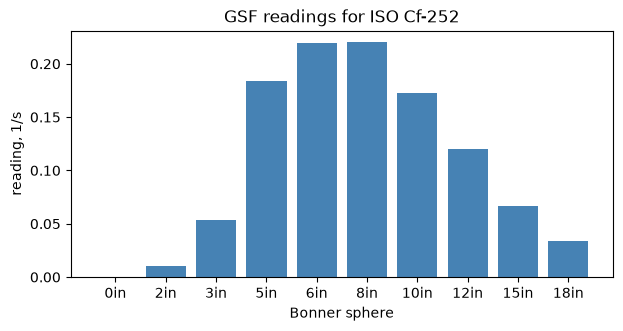

In [2]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(det.detector_names, [readings[k] for k in det.detector_names],
       color="steelblue")
ax.set_xlabel("Bonner sphere")
ax.set_ylabel("reading, 1/s")
ax.set_title("GSF readings for ISO Cf-252")
plt.show()

## 2. Run the new solvers

Each solver is run with its default strategy on the same GSF readings.
Regularization strengths are chosen moderate ($10^{-4}$) so that the
nonsmooth solvers (ADMM, subgradient, coordinate descent) demonstrate their
sparse/smoothing behaviour while the smooth ones stay close to the
least-squares fit. Frank-Wolfe and the entropy mirror map work on the
fluence simplex whose level is estimated from the data by NNLS
(`estimate_total_fluence`).

In [3]:
runners = {
    "PGD": lambda: det.unfold_pgd(
        readings, regularization=1e-4, max_iterations=2000
    ),
    "Frank-Wolfe": lambda: det.unfold_frank_wolfe(
        readings, max_iterations=2000
    ),
    "Mirror descent": lambda: det.unfold_mirror_descent(
        readings, mirror_map="entropy", max_iterations=2000
    ),
    "ADMM (L1+TV)": lambda: det.unfold_admm(
        readings, l1_penalty=1e-4, tv_penalty=1e-4, max_iterations=2000
    ),
    "L-BFGS-B": lambda: det.unfold_lbfgsb(
        readings, regularization=1e-4, max_iterations=2000
    ),
    "Coordinate descent": lambda: det.unfold_coordinate_descent(
        readings, l1_penalty=1e-4, max_iterations=2000
    ),
    "Subgradient": lambda: det.unfold_subgradient(
        readings, l1_penalty=1e-4, max_iterations=2000
    ),
    "Extragradient": lambda: det.unfold_extragradient(
        readings, max_iterations=2000
    ),
}

results, timings = {}, {}
for name, run in runners.items():
    t0 = time.perf_counter()
    results[name] = run()
    timings[name] = time.perf_counter() - t0
    print(
        f"{name:20s}  iterations = {results[name]['iterations']:5d}  "
        f"converged = {results[name]['converged']}  ({timings[name]:.2f} s)"
    )

PGD                   iterations =  2000  converged = False  (0.03 s)
Frank-Wolfe           iterations =  2000  converged = False  (0.06 s)
Mirror descent        iterations =  2000  converged = False  (0.53 s)
ADMM (L1+TV)          iterations =  2000  converged = False  (0.53 s)
L-BFGS-B              iterations =    37  converged = True  (0.01 s)
Coordinate descent    iterations =  2000  converged = False  (0.21 s)
Subgradient           iterations =  2000  converged = False  (0.03 s)
Extragradient         iterations =  2000  converged = False  (0.05 s)


## 3. Spectra comparison

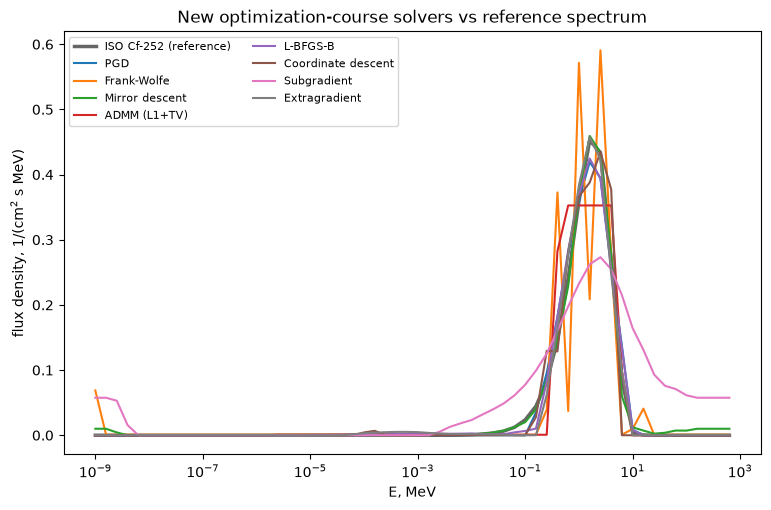

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(
    reference_spectrum["E_MeV"],
    reference_spectrum["Phi"],
    color="black", lw=2.5, alpha=0.6, label="ISO Cf-252 (reference)",
)
colors = plt.cm.tab10.colors
for i, (name, res) in enumerate(results.items()):
    ax.plot(res["energy"], res["spectrum"], color=colors[i % 10], lw=1.5, label=name)
ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_xlabel("E, MeV")
ax.set_ylabel("flux density, 1/(cm$^2$ s MeV)")
ax.set_title("New optimization-course solvers vs reference spectrum")
ax.legend(fontsize=8, ncol=2)
plt.show()

## 4. Fit quality and dose rates

`residual_norm` is $\|A x - b\|_2$; the dose rate column shows the
rotational ambient-equivalent quantity evaluated from the unfolded
spectrum. Iteration counts differ by orders of magnitude - quasi-Newton
(L-BFGS-B) converges in a few dozen steps, while first-order schemes and the
subgradient method need their full iteration budget. This is exactly the
trade-off discussed in lectures 7-9 of the course.

In [10]:
rows = []
for name, res in results.items():
    rows.append(
        {
            "method": name,
            "iterations": res["iterations"],
            "converged": res["converged"],
            "residual_norm": res["residual_norm"],
            "dose_ROT": res["doserates"]["ROT"],
            "runtime_s": timings[name],
        }
    )
summary = pd.DataFrame(rows).set_index("method")
summary.style.format(
    {"residual_norm": "{:.2e}", "dose_ROT": "{:.1f}", "runtime_s": "{:.2f}"}
)

,iterations,converged,residual_norm,dose_ROT,runtime_s
method,,,,,
PGD,2000,False,1.30e-03,212.5,0.03
Frank-Wolfe,2000,False,1.26e-03,213.0,0.06
Mirror descent,2000,False,1.33e-04,222.4,0.53
ADMM (L1+TV),2000,False,2.10e-03,210.8,0.53
L-BFGS-B,37,True,1.02e-03,212.2,0.01
Coordinate descent,2000,False,9.09e-04,207.1,0.21
Subgradient,2000,False,3.54e-02,338.2,0.03
Extragradient,2000,False,1.68e-03,210.3,0.05


## 5. Optimality certificates: duality gap and KKT residuals (seminars 9-10)

For the NNLS unfolding problem $\min_{x \ge 0} \tfrac12\|Ax-b\|^2$ the
Lagrange dual provides a *certificate*: for any primal-feasible $x$ one can
build a dual-feasible multiplier $\lambda = \max(0, A^\top(Ax-b))$ and
evaluate the dual objective. The duality gap $f(x) - g(\lambda)$ is an
upper bound on the distance of $x$ to the global optimum and vanishes at a
KKT point.

The helpers `nnls_duality_gap` and `nnls_kkt_residuals` (exported from
`bssunfold.core`) evaluate these quantities for the spectra produced above.
Small `relative_gap` and `stationarity` values indicate a nearly optimal
solution; the size of the active set shows how many energy bins sit at the
nonnegativity boundary.

In [6]:
from bssunfold.core import nnls_duality_gap, nnls_kkt_residuals

A = np.vstack([det.sensitivities[k] for k in det.detector_names])
b = np.array([readings[k] for k in det.detector_names])
print(f"response matrix A: {A.shape}, measurement vector b: {b.shape}")

gap_rows, kkt_rows = [], []
for name, res in results.items():
    x = np.asarray(res["spectrum"])
    gap = nnls_duality_gap(A, b, x)
    kkt = nnls_kkt_residuals(A, b, x)
    gap_rows.append(
        {
            "method": name,
            "primal": gap["primal_value"],
            "dual": gap["dual_value"],
            "gap": gap["duality_gap"],
            "rel_gap": gap["relative_gap"],
        }
    )
    kkt_rows.append(
        {
            "method": name,
            "stationarity": kkt["stationarity"],
            "complementarity": kkt["complementarity"],
            "feasibility": kkt["feasibility"],
            "active_bins": int(np.asarray(kkt["active_set"]).sum()),
        }
    )

display(pd.DataFrame(gap_rows).set_index("method").style.format("{:.3e}"))
display(pd.DataFrame(kkt_rows).set_index("method").style.format("{:.3e}"))

response matrix A: (10, 60), measurement vector b: (10,)


,primal,dual,gap,rel_gap
method,,,,
PGD,8.445e-07,-2.525e-06,3.369e-06,3.990e+00
Frank-Wolfe,7.888e-07,-8.882e-07,1.677e-06,2.126e+00
Mirror descent,8.885e-09,-5.310e-07,5.399e-07,6.076e+01
ADMM (L1+TV),2.197e-06,3.926e-14,2.197e-06,1.000e+00
L-BFGS-B,5.164e-07,-7.763e-06,8.279e-06,1.603e+01
Coordinate descent,4.135e-07,-1.268e-09,4.148e-07,1.003e+00
Subgradient,6.257e-04,-4.714e-03,5.339e-03,8.533e+00
Extragradient,1.409e-06,-2.878e-05,3.019e-05,2.142e+01


,stationarity,complementarity,feasibility,active_bins
method,,,,
PGD,8.626e-05,6.855e-08,0.000e+00,3.400e+01
Frank-Wolfe,4.932e-04,1.961e-06,0.000e+00,0.000e+00
Mirror descent,2.610e-05,5.405e-07,0.000e+00,0.000e+00
ADMM (L1+TV),6.474e-04,0.000e+00,0.000e+00,2.200e+01
L-BFGS-B,1.239e-04,4.443e-06,0.000e+00,3.400e+01
Coordinate descent,3.160e-04,0.000e+00,0.000e+00,5.000e+01
Subgradient,4.564e-03,4.536e-04,0.000e+00,2.800e+01
Extragradient,7.267e-05,2.297e-05,0.000e+00,3.600e+01


## 6. Regularization parameter selection by 1-D optimization (HW 1)

Model selection for unfolding can be reduced to a *univariate* minimization
of a scalar criterion over $\log_{10}\lambda$ - the one-dimensional
optimization topic of lecture 1 / homework 1. `select_regularization_1d`
implements the GCV, Morozov discrepancy and predictive-risk criteria and
searches the minimum with derivative-free 1-D routines: Brent (default),
golden section or dichotomy. The effective degrees of freedom entering GCV
are estimated by Hutchinson's randomized trace estimator, so the criterion
works for any solver.

The ISO Cf-252 readings of example 01 are essentially noiseless, so the
pure data-fit criteria (GCV, predictive risk) decrease monotonically towards
zero lambda and their minimum sits on the search boundary. Morozov's
**discrepancy principle** is the right criterion here: it targets a residual
norm of ``tau * noise_level * ||b||`` and therefore has a well-defined
interior minimum. We use it with an assumed 3% noise level and the exact
NNLS-Tikhonov surrogate (default ``solve_func=None``).

selected lambda = 3.710e-03  (log10 = -2.431, 15 criterion evaluations, search = brent)


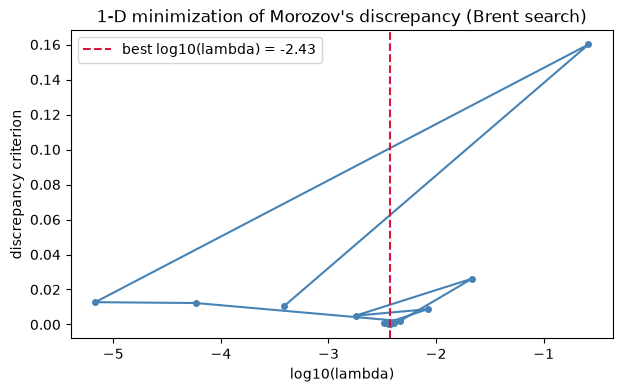

In [7]:
from bssunfold.core import select_regularization_1d

sel = select_regularization_1d(
    A, b, criterion="discrepancy", search="brent",
    noise_level=0.03, random_state=0,
)
print(
    f"selected lambda = {sel['best_lambda']:.3e}  "
    f"(log10 = {sel['best_log10_lambda']:.3f}, "
    f"{sel['iterations']} criterion evaluations, search = {sel['search']})"
)

hist = np.asarray(sel["criterion_history"], dtype=float)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist[:, 0], hist[:, 1], "o-", ms=4, color="steelblue")
ax.axvline(
    sel["best_log10_lambda"],
    color="crimson",
    ls="--",
    label=f"best log10(lambda) = {sel['best_log10_lambda']:.2f}",
)
ax.set_xlabel("log10(lambda)")
ax.set_ylabel("discrepancy criterion")
ax.set_title("1-D minimization of Morozov's discrepancy (Brent search)")
ax.legend()
plt.show()

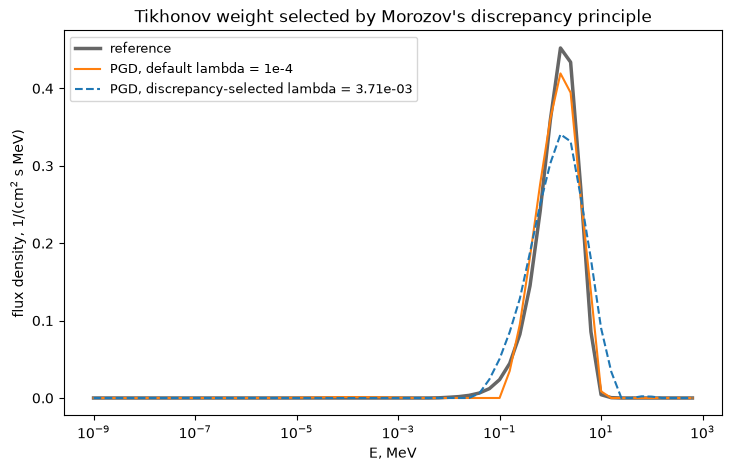

In [11]:
res_sel = det.unfold_pgd(
    readings, regularization=sel["best_lambda"], max_iterations=2000
)
res_default = det.unfold_pgd(readings, regularization=1e-4, max_iterations=2000)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(
    reference_spectrum["E_MeV"], reference_spectrum["Phi"],
    color="black", lw=2.5, alpha=0.6, label="reference",
)
ax.plot(
    res_default["energy"], res_default["spectrum"],
    color="tab:orange", lw=1.5, label="PGD, default lambda = 1e-4",
)
ax.plot(
    res_sel["energy"], res_sel["spectrum"],
    color="tab:blue", lw=1.5, ls="--",
    label=f"PGD, discrepancy-selected lambda = {sel['best_lambda']:.2e}",
)
ax.set_xscale("log")
ax.set_yscale("linear")
ax.set_xlabel("E, MeV")
ax.set_ylabel("flux density, 1/(cm$^2$ s MeV)")
ax.set_title("Tikhonov weight selected by Morozov's discrepancy principle")
ax.legend(fontsize=9)
plt.show()

## Summary

- The eight solvers cover the main algorithmic families of the MIPT
  optimization course - first-order projected/mirror/Frank-Wolfe schemes,
  quasi-Newton, coordinate descent, ADMM for structured penalties, the
  subgradient method for nonsmooth objectives and the extragradient for the
  robust saddle formulation.
- Lagrange duality gives free optimality certificates for every unfolding
  result (`nnls_duality_gap`, `nnls_kkt_residuals`).
- The regularization weight can be selected automatically by a
  one-dimensional minimization (`select_regularization_1d`) using
  Brent / golden-section / dichotomy searches.
- Monte-Carlo uncertainty with 20 spectra and the variance-reduction
  techniques of lecture 14 are demonstrated in
  `53-montecarlo-20-spectra.ipynb`; robustness against input noise is
  studied in `54-noise-robustness.ipynb`.